In [103]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = '/root/workspace/vllm-dynamic/examples/logs/'
BASELINE_DATA_PATH = f'{DATA_PATH}dllm_org_128'
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']
scheduling_policy = 'fcfs'
wt = 1.0

In [104]:
def get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR):
    output_tokens, reqs, mean_tpot, p99_tpot,  mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []

    filename = f'{DATA_DIR}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_recompute_{store_cache_layer}_{scheduling_policy}_wt{wt}.log'
    with open(filename, 'r') as f:
        lines = f.readlines()
        output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft_, p99_ttft_, mean_itl_, p99_itl_ = [], [], [], [], [], [], [], []
        for line in lines:
            if 'Output token throughput' in line:
                output_tokens_tgt.append(float(line.split()[-1]))
            if 'Request throughput' in line:
                reqs_tgt.append(float(line.split()[-1]))
            if 'Mean TPOT' in line:
                mean_tpot_.append(float(line.split()[-1]))
            if 'P99 TPOT' in line:
                p99_tpot_.append(float(line.split()[-1]))
            if 'Mean TTFT' in line:
                mean_ttft_.append(float(line.split()[-1]))
            if 'P99 TTFT' in line:
                p99_ttft_.append(float(line.split()[-1]))    
            if 'Mean ITL' in line:
                mean_itl_.append(float(line.split()[-1]))
            if 'P99 ITL' in line:
                p99_itl_.append(float(line.split()[-1]))    

    output_tokens.append(np.mean(output_tokens_tgt))
    reqs.append(np.mean(reqs_tgt))
    mean_tpot.append(np.mean(mean_tpot_))
    p99_tpot.append(np.mean(p99_tpot_))
    mean_ttft.append(np.mean(mean_ttft_))
    p99_ttft.append(np.mean(p99_ttft_))
    mean_itl.append(np.mean(mean_itl_))
    p99_itl.append(np.mean(p99_itl_))

    return output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl 

In [105]:
# plot throughput
def get_norm_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR)
    baseline_output_tokens, baseline_reqs, baseline_mean_tpot, baseline_p99_tpot, baseline_mean_ttft, baseline_p99_ttft, baseline_mean_itl, baseline_p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, BASELINE_DATA_PATH)
    # 计算增长百分比
    output_tokens_imp = [(output_tokens[i]-baseline_output_tokens) / baseline_output_tokens * 100 for i in range(len(output_tokens))]
    reqs_imp = [(reqs[i]-baseline_reqs) / baseline_reqs * 100 for i in range(len(reqs))]
    mean_tpot_imp = [(baseline_mean_tpot-mean_tpot[i]) / baseline_mean_tpot *100 for i in range(len(mean_tpot))]
    p99_tpot_imp = [(baseline_p99_tpot-p99_tpot[i]) / baseline_p99_tpot *100 for i in range(len(p99_tpot))]
    mean_ttft_imp = [(baseline_mean_ttft-mean_ttft[i]) / baseline_mean_ttft *100 for i in range(len(mean_ttft))]
    p99_ttft_imp = [(baseline_p99_ttft-p99_ttft[i]) / baseline_p99_ttft *100 for i in range(len(p99_ttft))]
    mean_itl_imp = [(baseline_mean_itl-mean_itl[i]) / baseline_mean_itl *100 for i in range(len(mean_itl))]
    p99_itl_imp = [(baseline_p99_itl-p99_itl[i]) / baseline_p99_itl *100 for i in range(len(p99_itl))]

    return output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp
    

In [106]:
# 绘制柱状图，对比swap和recompute的性能提升
def plot_bar(rate1, rate2, store_cache_layer, req_rate):
    print('rate1:', rate1)
    print('rate2:', rate2)
    fig = plt.figure(figsize=(6, 2.5), dpi=120)
    ax = fig.add_subplot(111)
    bar_width = 0.25
    ax.bar(np.arange(8), rate1, bar_width, label='0.5:0.5', color='skyblue', hatch=hatches[0])
    ax.bar(np.arange(8)+bar_width, rate2, bar_width, label='0.25:0.75', color='lightcoral', hatch=hatches[1])
    # bar3 = ax.bar(np.arange(8)+bar_width*2, rate3, bar_width, label='0.25:0.75', color='lightgreen', hatch=hatches[2])
    # 将数值标注在柱状图上
    for x, y in zip(np.arange(8), rate1):
        if y >= 0: ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=20, fontsize=8)
        else: ax.text(x, y, f'{y:.2f}', ha='center', va='top', rotation=70, fontsize=8)
    for x, y in zip(np.arange(8)+bar_width, rate2):
        if y >= 0: ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=20, fontsize=8)
        else: ax.text(x, y, f'{y:.2f}', ha='center', va='top', rotation=70, fontsize=8)
    # for x, y in zip(np.arange(8)+bar_width*2, rate3):
    #     if y >= 0: ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', rotation=0, fontsize=8)
    #     else: ax.text(x, y, f'{y:.0f}', ha='center', va='top', rotation=0, fontsize=8)
    ax.set_xticks(np.arange(8)+bar_width)
    ax.set_xticklabels(['out_toks', 'reqs', 'avg_tpot', 'p99_tpot', 'avg_ttft', 'p99_ttft', 'avg_itl', 'p99_itl'], rotation=0)
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    # ax.yaxis.set_major_locator(plt.MultipleLocator(10))
    # ax.set_ylim(min(min(rate1), min(rate2), min(rate3))*1.4, max(max(rate1), max(rate2), max(rate3))*1.4)
    ax.set_ylim(min(min(rate1), min(rate2))*1.4, max(max(rate1), max(rate2))*1.4)

    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    ax.title.set_text(f'req_rate={req_rate},cache_layer={store_cache_layer}')
    # ax.legend(bbox_to_anchor=(0.01, 1.05), loc='upper left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()    

In [107]:
def plot_fig(store_cache_layers, num_threads, model_name, gpu_utilization, req_rate):
    for store_cache_layer in store_cache_layers:
        output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
        rate_values = []
        for i in range(len(num_threads)):
            DATA_DIR = f'{DATA_PATH}dllm_org_128_multi_hfusion_{num_threads[i]}'
            output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, req_rate, req_rate, store_cache_layer, DATA_DIR)
            output_tokens_imps.append(np.mean(output_tokens_imp))
            reqs_imps.append(np.mean(reqs_imp))
            mean_tpot_imps.append(np.mean(mean_tpot_imp))
            p99_tpot_imps.append(np.mean(p99_tpot_imp))
            mean_ttft_imps.append(np.mean(mean_ttft_imp))
            p99_ttft_imps.append(np.mean(p99_ttft_imp))
            mean_itl_imps.append(np.mean(mean_itl_imp))
            p99_itl_imps.append(np.mean(p99_itl_imp))
            rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
        plot_bar(rate_values[0], rate_values[1], store_cache_layer, req_rate)        

rate1: [15.313446685407046, 14.61988304093566, 11.2821918727935, 7.967535234639042, 9.99158529187297, 8.85642727132961, 12.750223699348066, 8.089774915451711]
rate2: [16.70423842144045, 16.491228070175428, 12.760150615722907, 10.422854943453725, 11.739780932947422, 11.013613842972141, 13.323533171417633, 15.019984142138224]


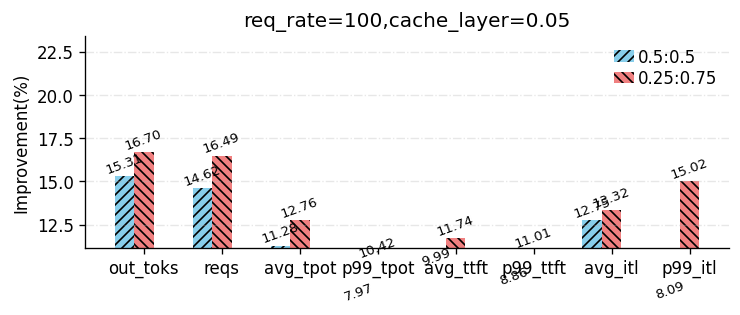

rate1: [-5.592433561564344, -14.28571428571428, 3.580206011686056, -1.0514431350598163, -9.530774096886969, -7.791587411378162, 5.89758314191551, 7.579137175837516]
rate2: [18.37240338865033, 8.214285714285742, 6.6270104210589595, 1.4946436971887491, -6.303179623772266, -5.117067266124845, 11.361729751323281, 15.16395362870306]


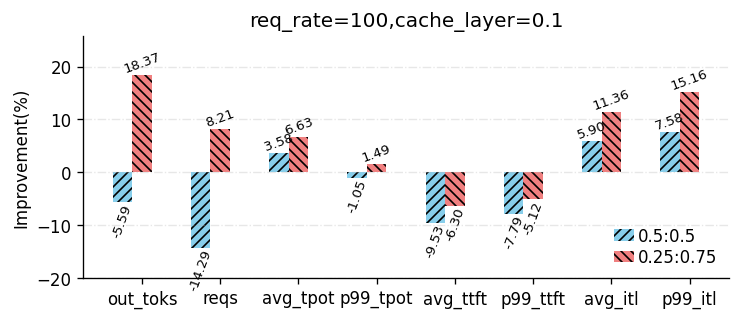

rate1: [-6.704531423632538, -6.627218934911242, -2.3628954376518245, 1.8708442670343355, 4.680717752832713, 3.461591508482183, -5.894303325133378, -11.552622162140665]
rate2: [0.2913939992591906, 2.2485207100591604, 2.124462263322685, 7.263929349759852, 1.713155530727941, 1.7661584087295372, 1.332264573371295, -0.9021510079122124]


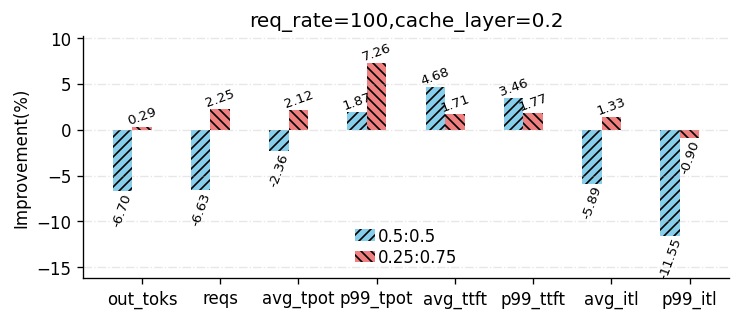

rate1: [16.126009425901934, 17.966101694915228, 3.792126229754637, 9.426634521280402, -3.5160178936829634, -4.619477259978675, 10.475829751250782, 11.911281025362804]
rate2: [-8.27660336796847, -12.203389830508483, -8.704741967273339, -9.424665218532919, 1.0966922235740713, -0.9057200427736504, -11.488795715594398, -8.337430489624301]


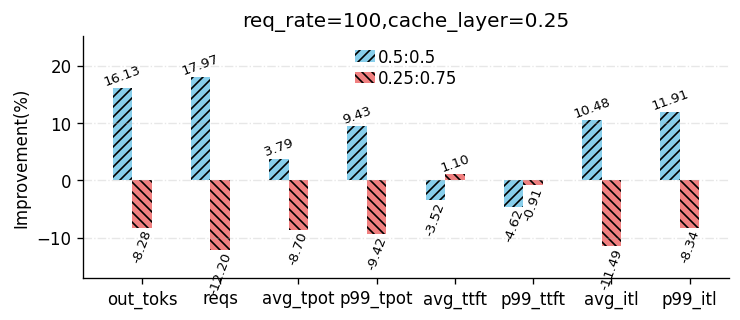

rate1: [6.947386150704253, 3.3142857142857043, 0.4706243869000585, -1.1100431679733065, 3.2714887692824037, 6.5308550762767865, 1.022367533343727, 5.0490712383668646]
rate2: [-1.143230098743068, -1.257142857142854, 0.3165073099242412, -0.6717994916292809, 2.1063282327934267, 3.2502386621585417, -2.2948777829674594, 6.496200152317987]


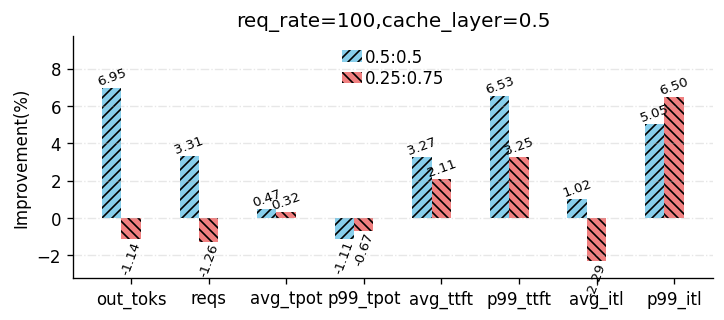

In [116]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.6
rates = ['0.5:0.5', '0.75:0.25']
num_threads = [64, 32]
store_cache_layers = [0.05, 0.1, 0.2, 0.25, 0.5]
req_rate = 100
plot_fig(store_cache_layers, num_threads, model_name, gpu_utilization, req_rate)

rate1: [1.8585226200213703, -0.9316770186335411, -0.8440551950097636, 3.027365144470672, -3.4622142313397983, -3.6179731521358325, 1.279317697228145, -28.224991409455676]
rate2: [1.3889762788649245, -2.5621118012422466, -24.86264255560455, -7.275013844599703, -14.571933297225492, -13.990047881683768, 2.1196663240428584, 16.58834111535585]


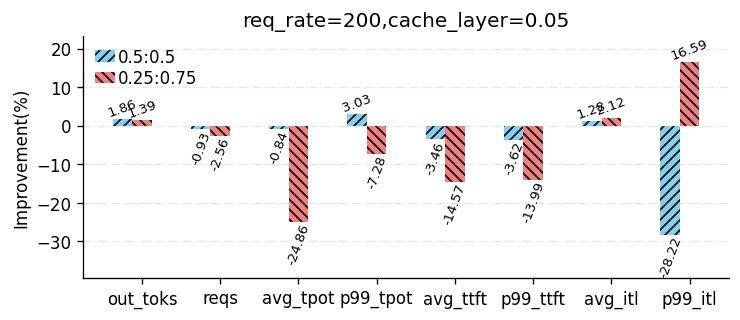

rate1: [-12.071736011477757, -0.6525911708253322, 1.4090479942325702, -34.55447703897441, 3.959835375846548, 5.2259198974208925, 3.2850506908040202, -46.98614656532341]
rate2: [-6.779053084648486, -5.566218809980807, -25.31889392076032, -43.9853373315756, -19.95870871533064, -18.48499749465474, -2.945917867762077, -6.590563602466649]


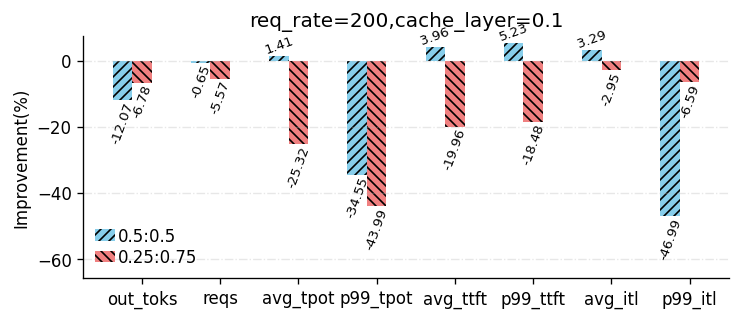

rate1: [18.229390184813468, -5.059101654846345, 14.526737498580255, 12.11911847866855, -6.508339857202166, -7.824224605300224, 4.3359224134231695, 35.25360215852862]
rate2: [24.300892918945145, -16.19385342789599, 24.728185112907717, 15.747341188328278, -21.761326933525016, -22.218668440412632, 10.467536368707895, 25.842456487140076]


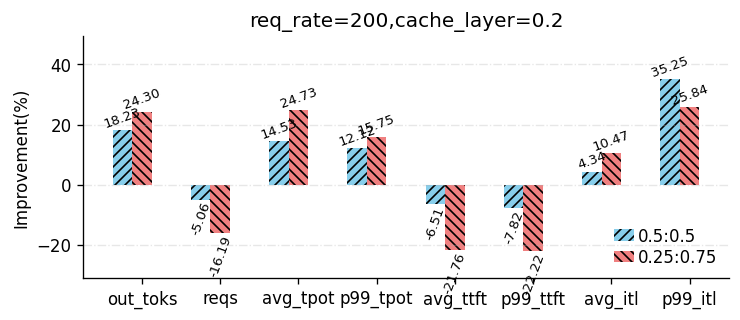

rate1: [1.8764894829551264, 9.240924092409236, -2.5497100633095338, -6.972295113406226, 1.9786204591765961, -0.2469010928394413, 6.546520978194048, -11.703488844913117]
rate2: [-1.4782578661969499, 16.06160616061605, -31.208987521685945, -39.95536097117566, -20.76348778220412, -14.351783924348336, -2.880658436213983, -45.773807910217144]


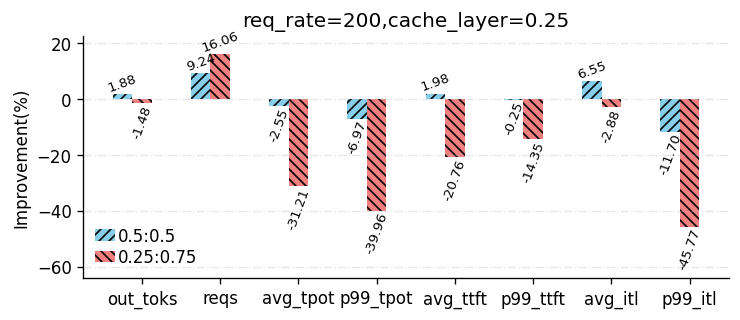

rate1: [-6.4811712433535025, -4.190800681430983, 1.009155896028349, 5.982368778052044, 5.339718786310802, 3.13690896474, -1.9673606669982535, 3.424564003493265]
rate2: [-1.189695777793979, 0.6246450880181784, -2.1314598226173245, -16.106088191290915, -4.324561980916615, -0.16892908480621405, -2.2067473570351415, -8.128897945501535]


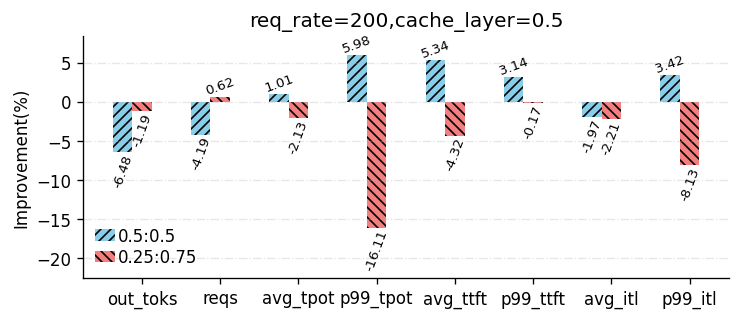

In [109]:
req_rate = 200
plot_fig(store_cache_layers, num_threads, model_name, gpu_utilization, req_rate)

rate1: [15.298703291644284, 0.5920205920205954, 23.569530857230287, 16.422110897993182, 19.47250901556123, 23.14283717102539, 15.379106852766627, 47.72116455604012]
rate2: [0.9867260032225986, -17.117117117117107, -42.486979296037454, -80.11999375632388, 4.928970382289219, 5.1373911363964915, 3.318635414249243, 74.63859956887646]


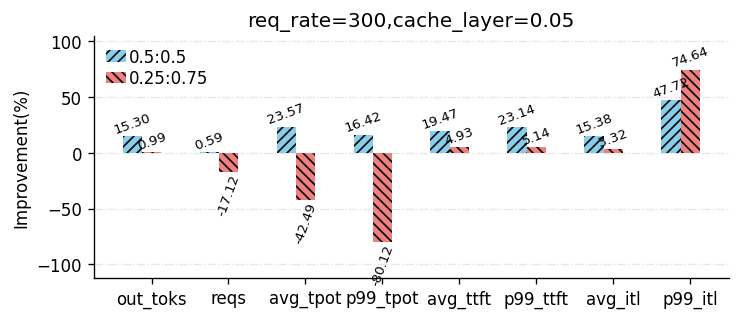

rate1: [-1.3026454495256221, 4.462474645030407, 23.670094841366378, 38.853135825411236, 11.931822120498198, 15.355912147568304, -0.6932435770751177, -9.413662395508938]
rate2: [-8.675518297274229, 6.085192697768768, 7.036360783743039, 31.854644980616172, -4.9862428415004425, -5.779733998002435, -10.964519515810277, -33.02916877989077]


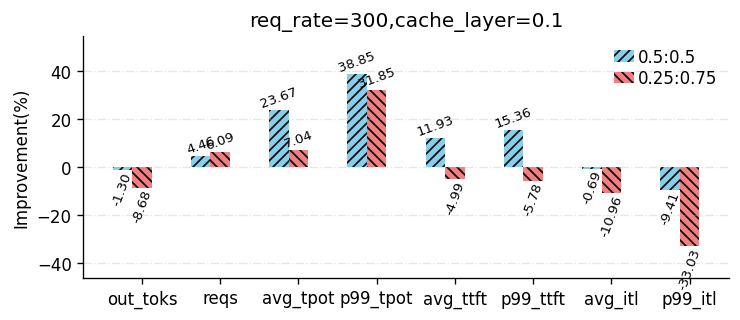

rate1: [1.4773431596464401, 14.69237832874198, -4.7058823529411775, -61.263528677335685, 6.825728215312159, 12.118269961743856, 3.369133441224069, 3.0501216127628883]
rate2: [10.669983613377628, 14.876033057851231, -3.229125445191917, -20.30611567539931, 7.530703396671826, 34.923564212289456, 7.612835728180728, 11.167543789784515]


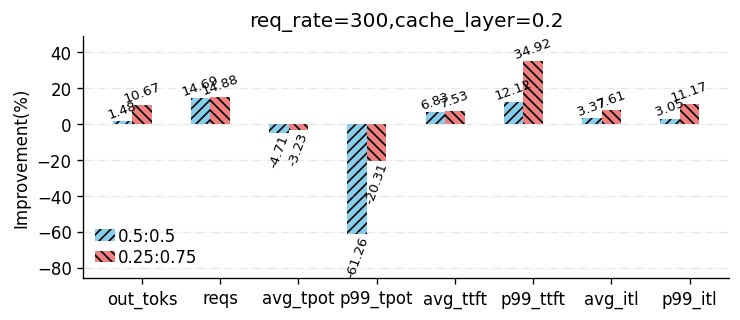

rate1: [5.519474477548047, 7.426470588235292, 10.271728261482718, 16.515806670797918, 15.216592961046151, 14.618566462374098, 10.136831198795127, 5.006896465116868]
rate2: [-3.4720025308446796, 1.9301470588235208, 1.817076985400835, 1.338511205565474, -17.827597279342953, -22.548265629540918, -11.656020679562909, -9.07115393872922]


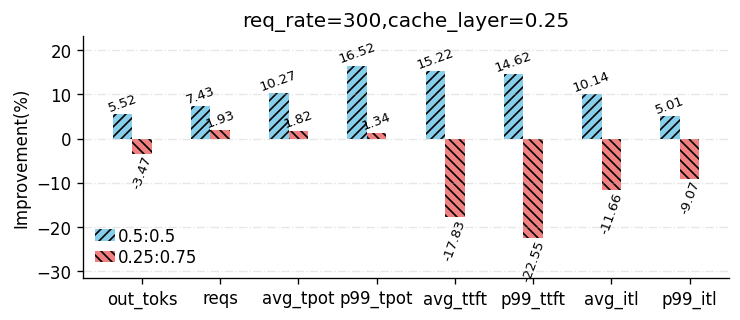

rate1: [7.210959856650015, 9.019607843137264, 5.470817870298582, 22.38594599815848, 6.820073291464941, 7.282638335296234, 4.657758489416786, 15.56785990213753]
rate2: [-1.8480382979861154, 1.8300653594771261, -4.019395118191856, 7.45871029356549, 1.0952161408636025, 0.4664168946430076, -4.061976549413735, -2.685986994591804]


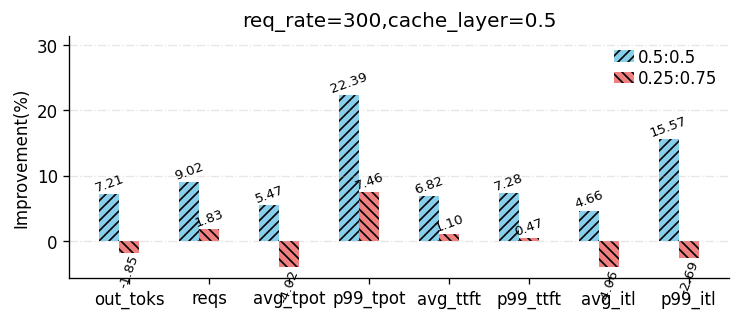

In [118]:
req_rate = 300
plot_fig(store_cache_layers, num_threads, model_name, gpu_utilization, req_rate)

rate1: [-19.756917234311885, 5.876288659793796, -267.11071046103376, -221.28086213402, -12.161662515080453, -17.348342056531862, -32.68029075711446, -276.6372649634476]
rate2: [-12.594188920368904, -12.371134020618578, -18.821761173392602, -24.37061039141572, -25.012845150451955, -29.290866529896743, -15.066173083620754, -12.141765639340116]


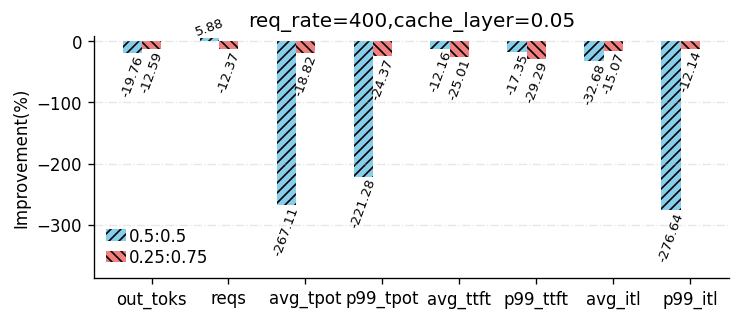

rate1: [-9.55003032140691, -0.8972845336481812, -14.524514116611991, -17.246692062009924, -9.247855497212317, -12.411351912382088, -2.641558441558431, 1.0480775535053763]
rate2: [-9.721801091570633, -8.353010625737896, -14.30997737013703, -41.6312086839341, -33.55512495899886, -33.63875510262165, -3.9772727272727124, -2.7851238701821734]


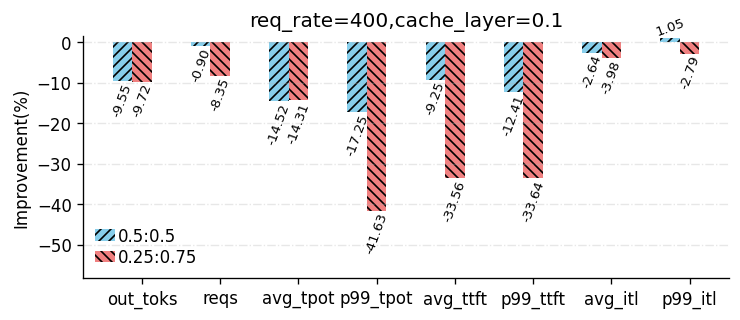

rate1: [3.3729982654995974, -5.842696629213472, 2.0220512345986585, -9.706318920056795, -5.706350742287386, -4.370389818242253, -2.1785593207847445, 11.51756637494441]
rate2: [-4.342301641724826, -6.741573033707855, -6.767337409513775, -23.335663278800034, -28.587398590849723, -7.731308868067388, -5.105906283625423, 7.494463303177875]


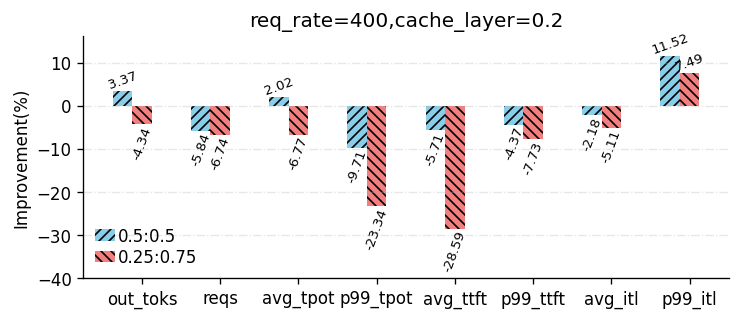

rate1: [5.625149899452072, 0.8730158730158826, -12.306551683771033, -16.80659670164917, -19.343287993084427, -18.45011197813204, -9.439523336643482, -57.27112947488514]
rate2: [-4.44394221722045, -1.4880952380952417, -25.34631443399538, -37.50360396724713, -31.7502621208651, -28.88724701659726, -13.192651439920564, -70.05527119114429]


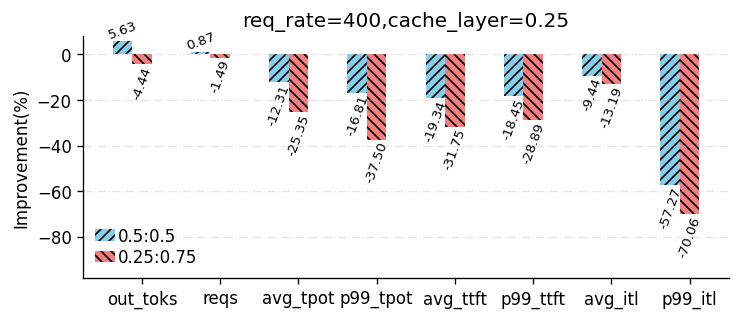

rate1: [-2.2063557836356003, -3.5199999999999987, -5.319833097270607, -20.372424319511566, -6.1352378807946195, -3.4004986878379806, -5.702952560698635, -21.958422939068104]
rate2: [-9.136040544417181, -10.900000000000011, -12.589002028863462, 23.926873177699942, -17.31156949254891, -12.604650539798095, -9.955695595150507, -22.228793309438476]


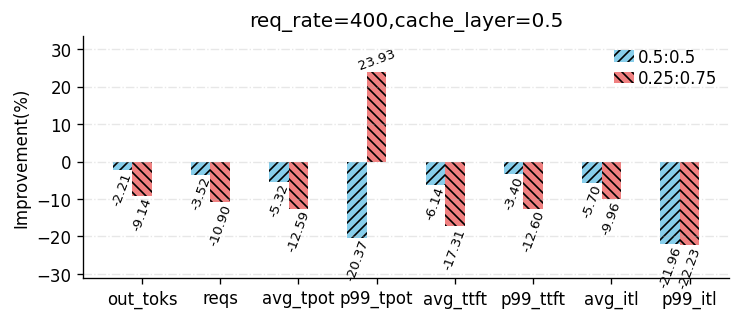

In [119]:
req_rate = 400
plot_fig(store_cache_layers, num_threads, model_name, gpu_utilization, req_rate)

rate1: [9.073207448375182, 0.12499999999998623, -3.9980068310190324, -11.688020261338872, 0.019385850312460328, -0.09940111254481893, 5.5866610213406265, 13.214067818380334]
rate2: [18.291226232941703, 7.374999999999993, -8.889785955096928, -32.50213587890882, -2.371535688226613, -2.1527307439654773, 9.749246412163593, 20.613421803936234]


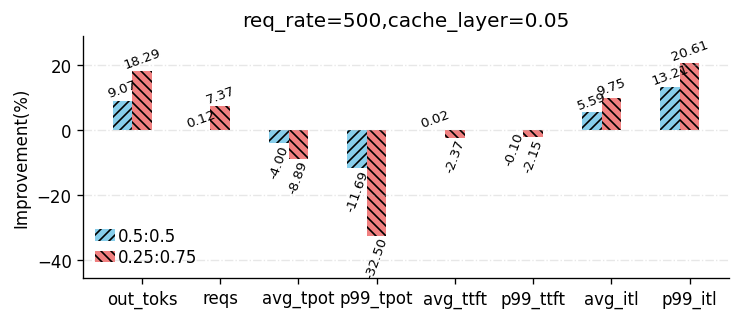

rate1: [2.530828827180422, -0.4385964912280868, 0.3222889189664768, 1.1819296797993897, 2.8410430333805055, 1.7875108157668933, -0.8539507548490933, -8.892702286768]
rate2: [1.4507966621565036, -1.023391812865498, -8.223526484137441, -30.425398364482238, -3.7313074545771276, -3.1194628423592388, 1.4830738282829188, -23.450407212037188]


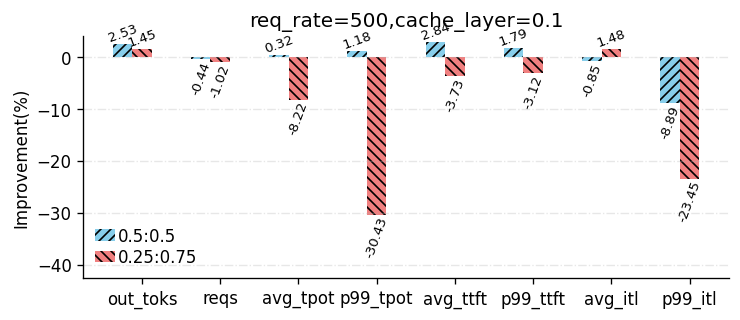

rate1: [-7.1934837306494925, -1.6450216450216562, -3.1054690808082412, 1.1361621214373385, -2.231114665136638, -3.097028839174547, -1.6167175835921315, -6.5684611944957725]
rate2: [6.6928227216512255, -3.4632034632034854, 7.618858081672057, -2.7389256482141024, -1.897895645319186, 3.2911148057211363, 0.3728297186524249, 7.249993672327807]


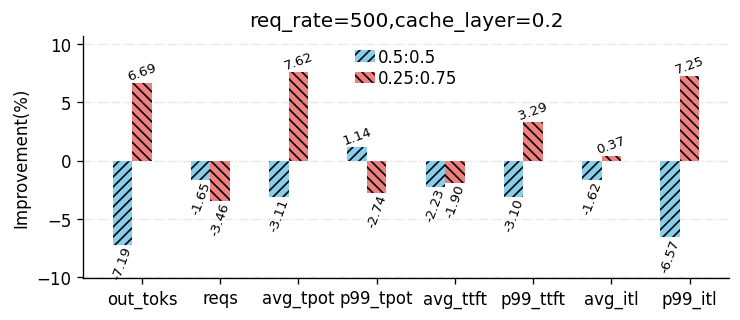

rate1: [13.764557317244257, 6.789606035205361, 0.7378774057783904, 11.301913928531924, -6.36327442204453, -3.1372957443000624, 3.88680316749219, -9.353156227150846]
rate2: [28.512570634080358, 15.088013411567472, 5.820832166758494, 28.997086698381086, 6.436635386687023, 4.4593847834205445, -6.174085875634929, -33.94491835242503]


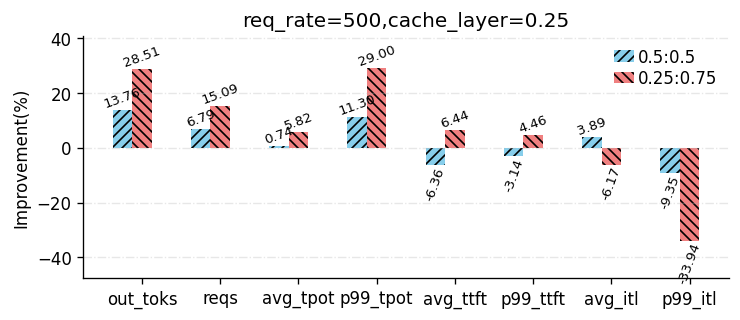

rate1: [1.4152523447967982, -1.8587360594795692, 1.853780830140698, 37.82621145116268, -4.859655009420278, -1.2595907680098695, -0.45973068016125, -2.563201604608853]
rate2: [1.4438644484144825, -4.9566294919454945, 3.3432790146124747, 52.22681962568465, -4.451258895762488, -3.5775352240866574, 0.5060468307745118, 3.5536376380333508]


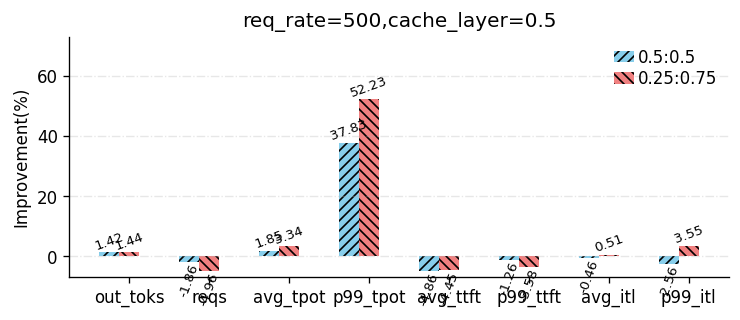

In [112]:
req_rate = 500
plot_fig(store_cache_layers, num_threads, model_name, gpu_utilization, req_rate)